setup and defining the store


In [1]:
import pandas as pd
import numpy as np
import requests
import sys
from pathlib import Path
from datetime import datetime, timedelta

sys.path.insert(0, str(Path.cwd().parent))

np.random.seed(42)

OUTPUT_DIR = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\boston-bodega")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Our store
STORE = {
    "store_nbr": 1,
    "city": "Dorchester",
    "state": "Massachusetts",
    "type": "A",
    "cluster": 1,
}

# Same 33 categories as Favorita with Boston-appropriate daily sales
CATEGORIES = {
    "AUTOMOTIVE": (3, 2), "BABY CARE": (5, 3), "BEAUTY": (8, 4),
    "BEVERAGES": (120, 35), "BOOKS": (2, 2), "BREAD/BAKERY": (65, 20),
    "CELEBRATION": (4, 3), "CLEANING": (25, 10), "DAIRY": (80, 25),
    "DELI": (30, 12), "EGGS": (40, 15), "FROZEN FOODS": (20, 8),
    "GROCERY I": (150, 40), "GROCERY II": (15, 7), "HARDWARE": (3, 2),
    "HOME AND KITCHEN I": (8, 5), "HOME AND KITCHEN II": (5, 3),
    "HOME APPLIANCES": (2, 2), "HOME CARE": (12, 6), "LADIESWEAR": (4, 3),
    "LAWN AND GARDEN": (3, 2), "LINGERIE": (3, 2),
    "LIQUOR,WINE,BEER": (35, 15), "MAGAZINES": (2, 2), "MEATS": (45, 18),
    "PERSONAL CARE": (18, 8), "PET SUPPLIES": (6, 4),
    "PLAYERS AND ELECTRONICS": (3, 2), "POULTRY": (35, 14),
    "PREPARED FOODS": (25, 10), "PRODUCE": (90, 30),
    "SCHOOL AND OFFICE SUPPLIES": (4, 3), "SEAFOOD": (15, 8),
}

print(f"Store: {STORE['city']}, {STORE['state']}")
print(f"Categories: {len(CATEGORIES)}")
print(f"Output folder: {OUTPUT_DIR}")

Store: Dorchester, Massachusetts
Categories: 33
Output folder: C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\boston-bodega


fetching boston weather 

In [2]:
start_date = "2024-01-01"
yesterday = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")

print(f"Fetching real Boston weather: {start_date} to {yesterday}")

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 42.3601,
    "longitude": -71.0589,
    "start_date": start_date,
    "end_date": yesterday,
    "daily": "temperature_2m_max,temperature_2m_min,apparent_temperature_max,precipitation_sum,rain_sum,snowfall_sum",
    "temperature_unit": "fahrenheit",
    "timezone": "America/New_York",
}

response = requests.get(url, params=params)
print(f"API response: {response.status_code}")

data = response.json()

weather = pd.DataFrame({
    "date": pd.to_datetime(data["daily"]["time"]),
    "temp_high": data["daily"]["temperature_2m_max"],
    "temp_low": data["daily"]["temperature_2m_min"],
    "temp_feels_like": data["daily"]["apparent_temperature_max"],
    "precipitation_mm": data["daily"]["precipitation_sum"],
    "rain_mm": data["daily"]["rain_sum"],
    "snow_mm": data["daily"]["snowfall_sum"],
}).fillna(0)

print(f"Got {len(weather)} days of real Boston weather ✅")
print(f"\nLast 5 days:")
print(weather.tail().to_string(index=False))

Fetching real Boston weather: 2024-01-01 to 2026-03-02
API response: 200
Got 792 days of real Boston weather ✅

Last 5 days:
      date  temp_high  temp_low  temp_feels_like  precipitation_mm  rain_mm  snow_mm
2026-02-26       39.1      25.3             33.4               0.0      0.0     0.00
2026-02-27       35.4      14.1             29.5               0.0      0.0     0.00
2026-02-28       43.6      23.4             36.5               0.0      0.0     0.00
2026-03-01       35.3      16.2             26.9               1.1      0.0     0.77
2026-03-02       22.8       5.5             16.0               0.0      0.0     0.00


generating sales data influenced by real weather


In [3]:
dates = pd.date_range(start_date, yesterday)

# Build weather lookup
weather_lookup = {}
for _, row in weather.iterrows():
    weather_lookup[row["date"].date()] = row

records = []
row_id = 0

for date in dates:
    dt = pd.Timestamp(date)
    dow = dt.dayofweek
    month = dt.month
    day = dt.day
    day_of_year = dt.dayofyear
    
    # Get real weather
    w = weather_lookup.get(dt.date(), None)
    temp = w["temp_high"] if w is not None else 65
    precip = w["precipitation_mm"] if w is not None else 0
    snow = w.get("snow_mm", 0) if w is not None else 0
    
    # Day of week effect
    dow_mult = {0: 0.85, 1: 0.88, 2: 0.90, 3: 0.92, 4: 1.05, 5: 1.20, 6: 1.10}[dow]
    
    # Payday
    payday_mult = 1.15 if day in [1, 2, 15, 16] else 1.0
    
    # Weather reduces foot traffic
    if snow > 10:
        traffic_mult = 0.5
    elif snow > 2:
        traffic_mult = 0.75
    elif precip > 15:
        traffic_mult = 0.8
    elif precip > 5:
        traffic_mult = 0.9
    else:
        traffic_mult = 1.0
    
    # Gradual growth
    days_from_start = (dt - dates[0]).days
    trend_mult = 1 + (days_from_start / 365) * 0.02
    
    for family, (base_mean, base_std) in CATEGORIES.items():
        
        # Category-specific weather effects
        weather_mult = 1.0
        
        if family in ["BEVERAGES", "FROZEN FOODS"]:
            if temp > 85: weather_mult = 1.35
            elif temp > 75: weather_mult = 1.15
            elif temp < 35: weather_mult = 0.85
        
        elif family in ["PREPARED FOODS", "BREAD/BAKERY"]:
            if temp < 35: weather_mult = 1.25
            elif temp < 50: weather_mult = 1.10
            elif temp > 85: weather_mult = 0.90
        
        elif family in ["LIQUOR,WINE,BEER"]:
            if temp > 70 and dow >= 4: weather_mult = 1.30
            elif temp > 70: weather_mult = 1.10
        
        elif family in ["PRODUCE", "DAIRY", "EGGS"]:
            weather_mult = 1 + 0.05 * np.sin(2 * np.pi * (day_of_year - 90) / 365)
        
        elif family in ["CLEANING", "HOME CARE"]:
            if month in [3, 4, 5]: weather_mult = 1.15
        
        elif family in ["SCHOOL AND OFFICE SUPPLIES"]:
            if month in [8, 9]: weather_mult = 2.5
            elif month == 1: weather_mult = 1.5
        
        elif family in ["CELEBRATION"]:
            if month == 12: weather_mult = 3.0
            elif month in [2, 10]: weather_mult = 2.0
        
        # Seasonal categories
        if family == "LAWN AND GARDEN":
            seasonal_mult = 2.0 if month in [4, 5, 6, 7, 8] else 0.3
        elif family == "SEAFOOD" and month in [2, 3, 4] and dow == 4:
            seasonal_mult = 1.8
        else:
            seasonal_mult = 1.0
        
        # Promotions (~15% of days)
        on_promo = 1 if np.random.random() < 0.15 else 0
        promo_mult = 1.20 if on_promo else 1.0
        
        # Final sales
        total_mult = (dow_mult * payday_mult * traffic_mult * 
                     trend_mult * weather_mult * seasonal_mult * promo_mult)
        
        raw_sales = base_mean * total_mult + np.random.normal(0, base_std)
        sales = max(0, round(raw_sales))
        
        records.append({
            "id": row_id,
            "date": dt.strftime("%Y-%m-%d"),
            "store_nbr": 1,
            "family": family,
            "sales": sales,
            "onpromotion": on_promo,
        })
        row_id += 1

train_df = pd.DataFrame(records)
print(f"Generated {len(train_df):,} sales records")
print(f"  {len(CATEGORIES)} categories × {len(dates)} days")

Generated 26,136 sales records
  33 categories × 792 days


generating fake holidays to simulate historical events data

In [4]:
holidays_list = []

fixed = [("01-01", "New Year's Day"), ("07-04", "Independence Day"),
         ("12-25", "Christmas"), ("12-31", "New Year's Eve")]

variable = {
    2024: [("01-15","MLK Day"),("02-14","Valentine's Day"),("02-19","Presidents Day"),
           ("03-31","Easter"),("05-27","Memorial Day"),("09-02","Labor Day"),
           ("10-31","Halloween"),("11-28","Thanksgiving"),("11-29","Black Friday")],
    2025: [("01-20","MLK Day"),("02-14","Valentine's Day"),("02-17","Presidents Day"),
           ("04-20","Easter"),("05-26","Memorial Day"),("09-01","Labor Day"),
           ("10-31","Halloween"),("11-27","Thanksgiving"),("11-28","Black Friday")],
    2026: [("01-19","MLK Day"),("02-14","Valentine's Day"),("02-16","Presidents Day"),
           ("04-05","Easter"),("05-25","Memorial Day"),("09-07","Labor Day"),
           ("10-31","Halloween"),("11-26","Thanksgiving"),("11-27","Black Friday")],
}

for year in [2024, 2025, 2026]:
    for md, name in fixed:
        holidays_list.append({"date": f"{year}-{md}", "type": "Holiday",
            "locale": "National", "locale_name": "United States",
            "description": name, "transferred": False})
    if year in variable:
        for md, name in variable[year]:
            holidays_list.append({"date": f"{year}-{md}", "type": "Holiday",
                "locale": "National", "locale_name": "United States",
                "description": name, "transferred": False})

holidays_df = pd.DataFrame(holidays_list)
print(f"Generated {len(holidays_df)} US holidays")
print(holidays_df.head(10).to_string(index=False))

Generated 39 US holidays
      date    type   locale   locale_name      description  transferred
2024-01-01 Holiday National United States   New Year's Day        False
2024-07-04 Holiday National United States Independence Day        False
2024-12-25 Holiday National United States        Christmas        False
2024-12-31 Holiday National United States   New Year's Eve        False
2024-01-15 Holiday National United States          MLK Day        False
2024-02-14 Holiday National United States  Valentine's Day        False
2024-02-19 Holiday National United States   Presidents Day        False
2024-03-31 Holiday National United States           Easter        False
2024-05-27 Holiday National United States     Memorial Day        False
2024-09-02 Holiday National United States        Labor Day        False


saving everything

In [5]:
# Save in Favorita-identical format
train_df.to_csv(OUTPUT_DIR / "train.csv", index=False)
pd.DataFrame([STORE]).to_csv(OUTPUT_DIR / "stores.csv", index=False)
holidays_df.to_csv(OUTPUT_DIR / "holidays_events.csv", index=False)
weather.to_csv(OUTPUT_DIR / "weather_boston.csv", index=False)

# Weather formatted for our pipeline
weather_pipeline = weather[["date", "temp_high", "temp_feels_like", "precipitation_mm"]].copy()
weather_pipeline["is_precipitation"] = (weather_pipeline["precipitation_mm"] > 0.5).astype(int)
weather_pipeline["humidity"] = 65
weather_pipeline.to_csv(OUTPUT_DIR / "weather_pipeline.csv", index=False)

print(f"✅ All files saved to {OUTPUT_DIR}\n")
for f in OUTPUT_DIR.glob("*.csv"):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<30s} {size:.0f} KB")

✅ All files saved to C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\boston-bodega

  holidays_events.csv            2 KB
  stores.csv                     0 KB
  train.csv                      919 KB
  weather_boston.csv             30 KB
  weather_pipeline.csv           24 KB


sanity check

C:\Users\syeds\AppData\Local\Temp\ipykernel_28096\1094916328.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bev_monthly = bev.set_index("date")["sales"].resample("M").mean()
C:\Users\syeds\AppData\Local\Temp\ipykernel_28096\1094916328.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temp_monthly = weather.set_index("date")["temp_high"].resample("M").mean()


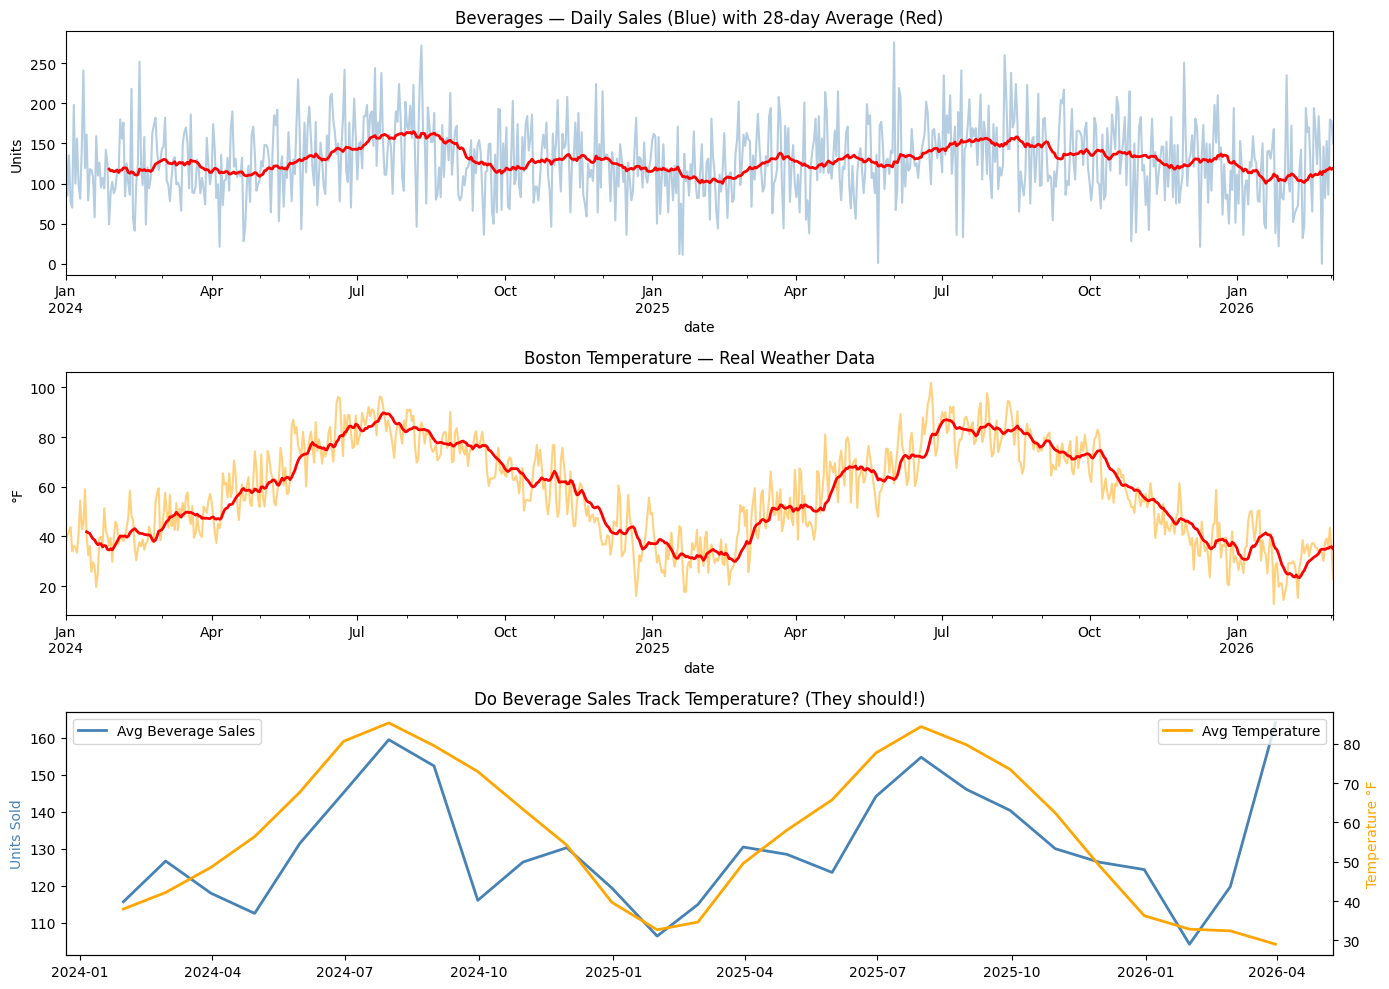


Last 7 days of Beverage sales:
  Tuesday Feb 24: 146 units | 30°F | 
  Wednesday Feb 25: 82 units | 38°F | 
  Thursday Feb 26: 153 units | 39°F | 
  Friday Feb 27: 86 units | 35°F | 
  Saturday Feb 28: 180 units | 44°F | 🏷️ Promo
  Sunday Mar 01: 178 units | 35°F | 
  Monday Mar 02: 150 units | 23°F | 


In [7]:
import matplotlib.pyplot as plt

bev = train_df[train_df.family == "BEVERAGES"].copy()
bev["date"] = pd.to_datetime(bev["date"])

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Sales over time
bev.set_index("date")["sales"].plot(ax=axes[0], alpha=0.4, color="steelblue")
bev.set_index("date")["sales"].rolling(28).mean().plot(ax=axes[0], color="red", linewidth=2)
axes[0].set_title("Beverages — Daily Sales (Blue) with 28-day Average (Red)")
axes[0].set_ylabel("Units")

# Weather over time
weather.set_index("date")["temp_high"].plot(ax=axes[1], color="orange", alpha=0.5)
weather.set_index("date")["temp_high"].rolling(14).mean().plot(ax=axes[1], color="red", linewidth=2)
axes[1].set_title("Boston Temperature — Real Weather Data")
axes[1].set_ylabel("°F")

# Overlay: do sales track temperature?
ax3 = axes[2]
bev_monthly = bev.set_index("date")["sales"].resample("M").mean()
temp_monthly = weather.set_index("date")["temp_high"].resample("M").mean()

ax3.plot(bev_monthly.index, bev_monthly.values, color="steelblue", linewidth=2, label="Avg Beverage Sales")
ax3_twin = ax3.twinx()
ax3_twin.plot(temp_monthly.index, temp_monthly.values, color="orange", linewidth=2, label="Avg Temperature")
ax3.set_title("Do Beverage Sales Track Temperature? (They should!)")
ax3.set_ylabel("Units Sold", color="steelblue")
ax3_twin.set_ylabel("Temperature °F", color="orange")
ax3.legend(loc="upper left")
ax3_twin.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Last week sanity check
print("\nLast 7 days of Beverage sales:")
for _, row in bev.tail(7).iterrows():
    dt = pd.Timestamp(row["date"])
    w = weather_lookup.get(dt.date(), None)
    temp_str = f"{w['temp_high']:.0f}°F" if w is not None else "?"
    print(f"  {dt.strftime('%A %b %d')}: {row['sales']} units | {temp_str} | {'🏷️ Promo' if row['onpromotion'] else ''}")

testing if existing pipelines work with new data

In [8]:
from feature_store.engineer import build_features, get_feature_columns
from model.evaluate import compute_wmape
import xgboost as xgb

# Load Boston data exactly like we loaded Favorita
BOSTON_DATA = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\boston-bodega")

train_boston = pd.read_csv(BOSTON_DATA / "train.csv", parse_dates=["date"])
holidays_boston = pd.read_csv(BOSTON_DATA / "holidays_events.csv", parse_dates=["date"])
weather_boston = pd.read_csv(BOSTON_DATA / "weather_pipeline.csv", parse_dates=["date"])

# Same code as before — just different DATA_RAW
store1 = train_boston[train_boston.store_nbr == 1].copy()
bev = store1[store1.family == "BEVERAGES"].sort_values("date").reset_index(drop=True)

features = build_features(bev, holidays_boston, weather_df=weather_boston).dropna()
feat_cols = get_feature_columns(features)

# Use last 30 days as test
SPLIT_DATE = (pd.Timestamp(yesterday) - pd.Timedelta(days=30)).strftime("%Y-%m-%d")

train_data = features[features.index < SPLIT_DATE]
test_data = features[features.index >= SPLIT_DATE]

X_train, y_train = train_data[feat_cols], train_data["sales"]
X_test, y_test = test_data[feat_cols], test_data["sales"]

model = xgb.XGBRegressor(
    objective="reg:tweedie", tweedie_variance_power=1.6,
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    early_stopping_rounds=30)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
preds = np.maximum(model.predict(X_test), 0)

wmape = compute_wmape(y_test.values, preds)
baseline = compute_wmape(y_test.values, test_data["sales_same_dow_avg_4w"].fillna(0).values)

print("=" * 55)
print("  BOSTON BODEGA — Beverages — Real Weather")
print("=" * 55)
print(f"  Baseline WMAPE:  {baseline:.1%}")
print(f"  XGBoost WMAPE:   {wmape:.1%}")
print(f"  Improvement:     {(baseline - wmape) / baseline * 100:.1f}%")
print("=" * 55)
print(f"\n✅ Pipeline works with Boston data — zero code changes!")

  BOSTON BODEGA — Beverages — Real Weather
  Baseline WMAPE:  42.8%
  XGBoost WMAPE:   32.3%
  Improvement:     24.6%

✅ Pipeline works with Boston data — zero code changes!
